CONECCTIVIDAD REGIONES Y FRONTERAS 

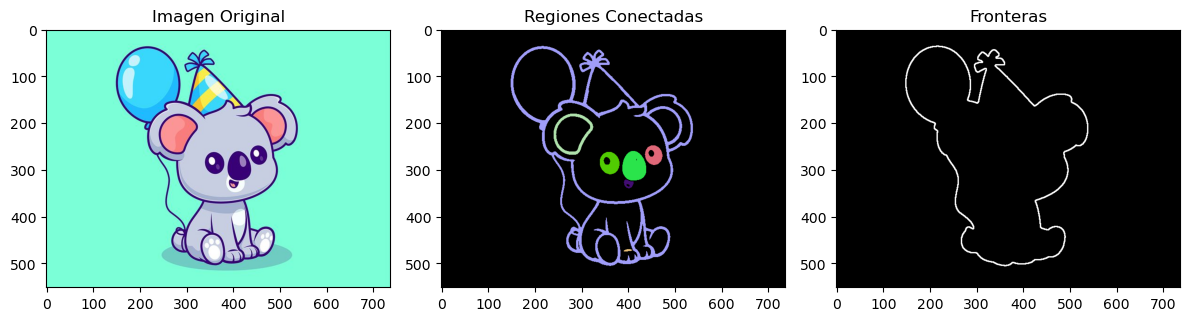

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imgKoala.jpg')
#img = cv2.imread('Fond.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Combinacion de tecnicas
blur = cv2.GaussianBlur(gray, (7, 7), 0) #Valores impares
_,binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

#Encontrar contornos o regiones
num_l, label =cv2.connectedComponents(binary)

#Identificar por colores
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)

#Fondo negro
color[0] = [0, 0, 0]
colorear = color[label]

#Encontrar fronteras
contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, (255, 0, 0), 2)


plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1, 3, 2)
plt.imshow(colorear)
plt.title('Regiones Conectadas')

plt.subplot(1, 3, 3)
plt.imshow(contorno_fin,cmap='gray')
plt.title('Fronteras')
plt.tight_layout()
plt.show()

CONTEO

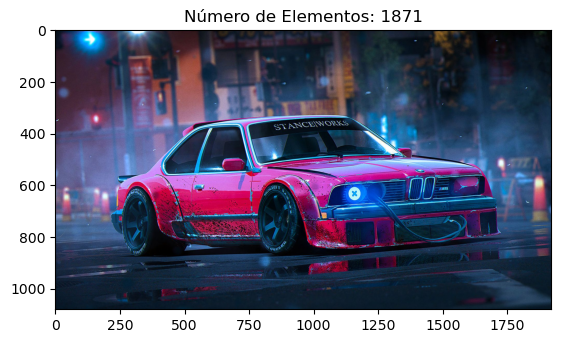

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure


def contar_elementos(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    e_img = measure.label(binary, connectivity=2) # 2= conectividad 4, 1= conectividad 8
    num_obj = np.max(e_img)
    return num_obj

imagen = cv2.imread('BMW_635.jpg')
conteo = contar_elementos(imagen)



plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f'Número de Elementos: {conteo}')
plt.show()


Región 1: (RGB 110, 231, 146) Objetos 1444012
Región 2: (RGB 119, 217, 54) Objetos 9
Región 3: (RGB 15, 228, 146) Objetos 80
Región 4: (RGB 14, 120, 144) Objetos 144
Región 5: (RGB 86, 111, 24) Objetos 5
Región 6: (RGB 22, 102, 191) Objetos 10
Región 7: (RGB 211, 157, 4) Objetos 3
Región 8: (RGB 40, 213, 145) Objetos 15
Región 9: (RGB 210, 84, 18) Objetos 1
Región 10: (RGB 192, 7, 211) Objetos 5
Región 11: (RGB 4, 185, 193) Objetos 2
Región 12: (RGB 74, 38, 59) Objetos 1145
Región 13: (RGB 251, 85, 20) Objetos 1
Región 14: (RGB 60, 244, 254) Objetos 179
Región 15: (RGB 245, 203, 123) Objetos 6
Región 16: (RGB 66, 92, 146) Objetos 139
Región 17: (RGB 43, 147, 158) Objetos 215
Región 18: (RGB 46, 246, 147) Objetos 24014
Región 19: (RGB 141, 106, 94) Objetos 1
Región 20: (RGB 12, 248, 159) Objetos 15319
Región 21: (RGB 143, 195, 168) Objetos 335
Región 22: (RGB 163, 27, 49) Objetos 144
Región 23: (RGB 162, 28, 13) Objetos 7
Región 24: (RGB 33, 134, 133) Objetos 1
Región 25: (RGB 151, 91, 

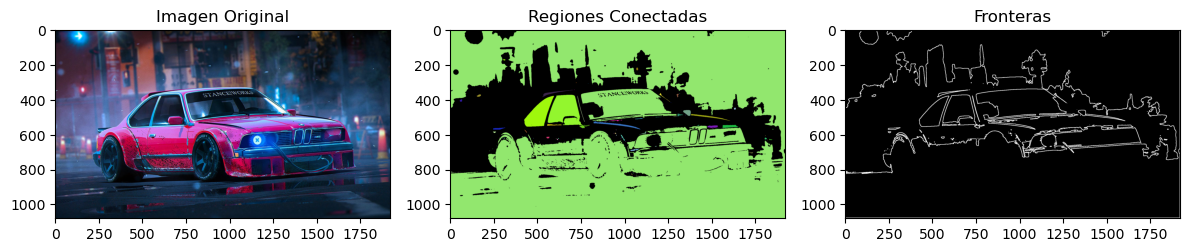

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

#img = cv2.imread('imgKoala.jpg')
img = cv2.imread('BMW_635.jpg')
#img = cv2.imread('imagen1.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Combinacion de tecnicas
blur = cv2.GaussianBlur(gray, (7, 7), 0) #Valores impares
_,binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

#Encontrar contornos o regiones
num_l, label =cv2.connectedComponents(binary)

#Identificar por colores
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)

#Fondo negro
color[0] = [0, 0, 0]
colorear = color[label]


# Se recorren todas las regiones (desde 1 para ignorar el fondo)
for i in range(1, num_l):

    # Obtener el color asignado a la región i
    b, g, r = color[i]

    # Contar cantidad de píxeles de la región
    cantidad_objetos = np.sum(label == i)

    # Mostrar región, color RGB y cantidad de objetos
    print(f"Región {i}: (RGB {r}, {g}, {b}) Objetos {cantidad_objetos}")

print(f"Conteo de las regiones: {num_l - 1}\n")

#Encontrar fronteras
contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, (255, 0, 0), 2)


plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1, 3, 2)
plt.imshow(colorear)
plt.title('Regiones Conectadas')

plt.subplot(1, 3, 3)
plt.imshow(contorno_fin,cmap='gray')
plt.title('Fronteras')
plt.tight_layout()
plt.show()